# Preperation of electric vehicle data

In [1]:
import pandas as pd
import numpy as np

In [2]:
days_2015 = pd.date_range(start='2015', end='2015-12-31')

### Number of vehicles in each zone

Read raw data

In [3]:
vehicles = pd.read_excel('Raw/total_cars_fylke_2015.xlsx', header=None).iloc[4:23].rename(columns={0:'Fylke', 1:'Number of vehicles'})

Aggregate to regions:

NO03 Oslo

NO11 Rogaland

NO15 Møre og Romsdal

NO18 Nordland

NO30 Viken

NO34 Innlandet

NO38 Vestfold og Telemark

NO42 Agder

NO46 Vestland

NO50 Trøndelag

NO54 Troms og Finnmark

In [4]:
vehicles

,Fylke,Number of vehicles
4,01 Østfold (-2019),146266
5,02 Akershus (-2019),323788
6,03 Oslo,279211
7,04 Hedmark (-2019),114140
8,05 Oppland (-2019),108575
9,06 Buskerud (-2019),157745
10,07 Vestfold (-2019),125469
11,08 Telemark (-2019),90030
12,09 Aust-Agder (-2019),59859
13,10 Vest-Agder (-2019),85645


In [5]:
vehicle_dict ={}

vehicle_dict['NO03'] = vehicles.loc[6, 'Number of vehicles']
vehicle_dict['NO11'] = vehicles.loc[14, 'Number of vehicles']
vehicle_dict['NO15'] = vehicles.loc[17, 'Number of vehicles']
vehicle_dict['NO18'] = vehicles.loc[20, 'Number of vehicles']
vehicle_dict['NO30'] = vehicles.loc[4, 'Number of vehicles'] + vehicles.loc[5, 'Number of vehicles'] + vehicles.loc[9, 'Number of vehicles']
vehicle_dict['NO34'] = vehicles.loc[7, 'Number of vehicles'] + vehicles.loc[8, 'Number of vehicles']
vehicle_dict['NO38'] = vehicles.loc[10, 'Number of vehicles'] + vehicles.loc[11, 'Number of vehicles']
vehicle_dict['NO42'] = vehicles.loc[12, 'Number of vehicles'] + vehicles.loc[13, 'Number of vehicles']
vehicle_dict['NO46'] = vehicles.loc[15, 'Number of vehicles'] + vehicles.loc[16, 'Number of vehicles']
vehicle_dict['NO50'] = vehicles.loc[18, 'Number of vehicles'] + vehicles.loc[19, 'Number of vehicles']
vehicle_dict['NO54'] =  vehicles.loc[21, 'Number of vehicles'] + vehicles.loc[22, 'Number of vehicles']

In [6]:
vehicles = pd.Series(vehicle_dict)

Scale number of vehicles to 2050 level

In [20]:
vehicles_2050 = ((vehicles/vehicles.sum())*3250000).round().astype(int)

Write to file

In [21]:
vehicles_2050.to_csv('vehicles_zones.tsv', sep = '\t', header = False)

### When cars are connected to the grid

Plug-in data

In [8]:
plug_in_weekday = [0.008, 0.003, 0.002, 0.001, 0.0, 0.001, 0.003, 0.012, 0.012, 0.008, 0.013, 0.016, 0.023, 0.029, 0.047, 0.122, 0.183, 0.086, 0.079, 0.106, 0.094, 0.069, 0.057, 0.026]
plug_in_weekend = [0.023, 0.014, 0.007, 0.007, 0.002, 0.004, 0.005, 0.005, 0.007, 0.008, 0.011, 0.023, 0.044, 0.075, 0.080, 0.117, 0.088, 0.104, 0.099, 0.089, 0.062, 0.047, 0.050, 0.029]

Create yearly plug-in data

In [9]:
plug_in = {}

for i in days_2015:
    if i.day_name() in ['Saturday', 'Sunday']:
        plug_in[i] = plug_in_weekend

    else:
        plug_in[i] = plug_in_weekday

In [10]:
plug_in = pd.DataFrame(plug_in).melt(ignore_index=False)

Plug-out data

In [11]:
plug_out_weekday = [0.003, 0.002, 0.001, 0.002, 0.0, 0.071, 0.221, 0.082, 0.048, 0.045, 0.058, 0.043, 0.033, 0.036, 0.036, 0.049, 0.084, 0.062, 0.045, 0.033, 0.024, 0.013, 0.006, 0.003]
plug_out_weekend = [0.006, 0.007, 0.002, 0.001, 0.003, 0.003, 0.067, 0.176, 0.053, 0.057, 0.061, 0.055, 0.051, 0.055, 0.049, 0.052, 0.057, 0.069, 0.057, 0.037, 0.025, 0.028, 0.018, 0.011]

Create yearly plug-out data

In [12]:
plug_out = {}

for i in days_2015:
    if i.day_name() in ['Saturday', 'Sunday']:
        plug_out[i] = plug_out_weekend

    else:
        plug_out[i] = plug_out_weekday

In [13]:
plug_out = pd.DataFrame(plug_out).melt(ignore_index=False)

Calculate the fraction of EVs connected at any hour

In [14]:
connected = pd.DataFrame({'plug_in':plug_in.reset_index().value, 'plug_out':plug_out.reset_index().value})

In [15]:
connected['change'] = connected['plug_in'] - connected['plug_out']

In [16]:
initial_connected = 0.75
result = []

for i in range(len(connected['change'])):
    if i == 0:
        result.append(initial_connected + connected['change'][i])
    else:
        result.append(result[i-1] + connected['change'][i])

In [17]:
connected['connected'] = result

Write to file

In [18]:
connected['connected'].to_csv('connected_vehicles.tsv', sep = '\t', header = False)

Plot

In [19]:
import matplotlib.pyplot as plt

In [20]:
plt.rcParams.update({'font.size': 18})

In [21]:
plot_data = connected.set_index(pd.date_range(start='2015', end='2015-12-31 23', freq='h'))
plot_data['connected_%'] = plot_data.connected*100

In [113]:
one = pd.DataFrame()

one['a'] = {'time':pd.Timestamp('2015-01-05 00:00:00'), 'value':100}
one['b'] = {'time':pd.Timestamp('2015-01-05 01:00:00'), 'value':100}
one['c'] = {'time':pd.Timestamp('2015-01-05 02:00:00'), 'value':100}
one['d'] = {'time':pd.Timestamp('2015-01-05 03:00:00'), 'value':100}
one['f'] = {'time':pd.Timestamp('2015-01-05 04:00:00'), 'value':100}
one['g'] = {'time':pd.Timestamp('2015-01-05 05:00:00'), 'value':100}
one['h'] = {'time':pd.Timestamp('2015-01-05 06:00:00'), 'value':100}
one['i'] = {'time':pd.Timestamp('2015-01-05 06:00:01'), 'value':0}
one['j'] = {'time':pd.Timestamp('2015-01-05 07:00:00'), 'value':0}
one['k'] = {'time':pd.Timestamp('2015-01-05 08:00:00'), 'value':0}
one['l'] = {'time':pd.Timestamp('2015-01-05 09:00:00'), 'value':0}
one['m'] = {'time':pd.Timestamp('2015-01-05 10:00:00'), 'value':0}
one['n'] = {'time':pd.Timestamp('2015-01-05 11:00:00'), 'value':0}
one['o'] = {'time':pd.Timestamp('2015-01-05 12:00:00'), 'value':0}
one['p'] = {'time':pd.Timestamp('2015-01-05 13:00:00'), 'value':0}
one['q'] = {'time':pd.Timestamp('2015-01-05 14:00:00'), 'value':0}
one['r'] = {'time':pd.Timestamp('2015-01-05 15:00:00'), 'value':0}
one['s'] = {'time':pd.Timestamp('2015-01-05 16:00:00'), 'value':0}
one['t'] = {'time':pd.Timestamp('2015-01-05 17:00:00'), 'value':0}
one['u'] = {'time':pd.Timestamp('2015-01-05 18:00:00'), 'value':0}
one['v'] = {'time':pd.Timestamp('2015-01-05 18:00:01'), 'value':100}
one['w'] = {'time':pd.Timestamp('2015-01-05 19:00:00'), 'value':100}
one['x'] = {'time':pd.Timestamp('2015-01-05 20:00:00'), 'value':100}
one['y'] = {'time':pd.Timestamp('2015-01-05 21:00:00'), 'value':100}
one['z'] = {'time':pd.Timestamp('2015-01-05 22:00:00'), 'value':100}
one['æ'] = {'time':pd.Timestamp('2015-01-05 23:00:00'), 'value':100}

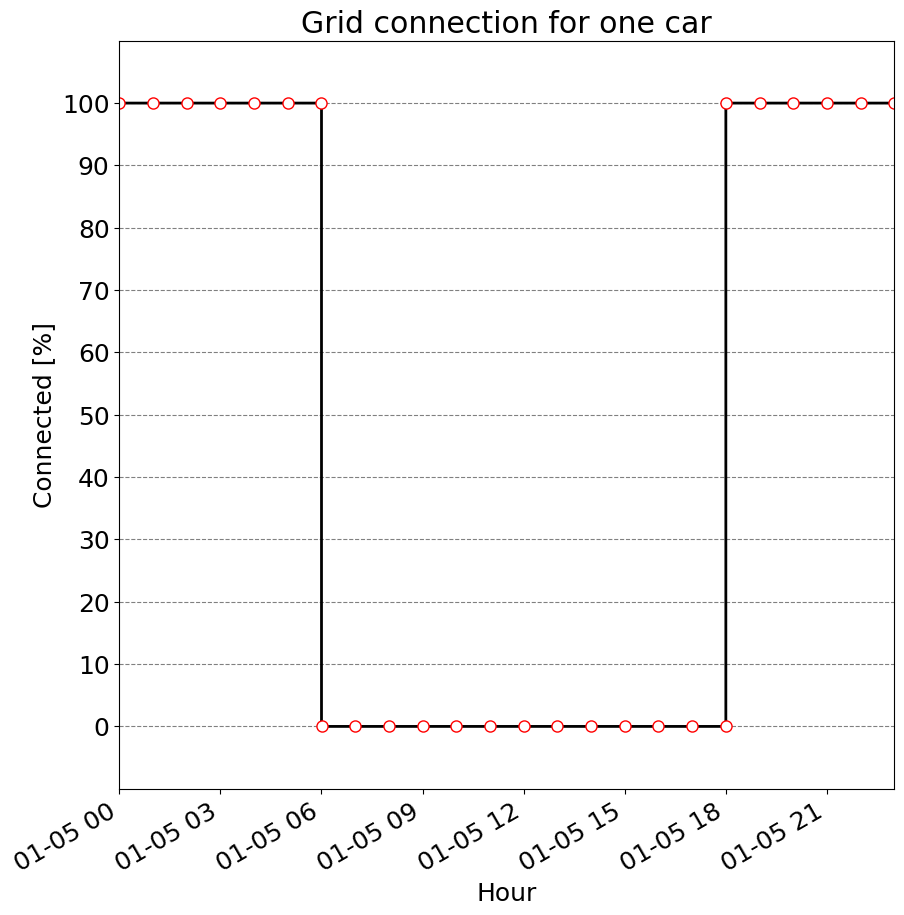

In [145]:
one.T.set_index('time').plot(figsize=(10,11), style='o-', color='black', alpha=1, markersize=8, markerfacecolor='white', linewidth=2, markeredgecolor='red', legend=None)

plt.xlabel('Hour')
plt.ylabel('Connected [%]')
plt.xlim(pd.Timestamp('2015-01-05 00:00:00'),pd.Timestamp('2015-01-05 23:00:00'))
plt.ylim([-10,110])
plt.yticks([0,10,20,30,40,50,60,70,80,90,100])
plt.grid(axis='y', color='gray', zorder=0, linestyle='--')
plt.title('Grid connection for one car')
plt.show()

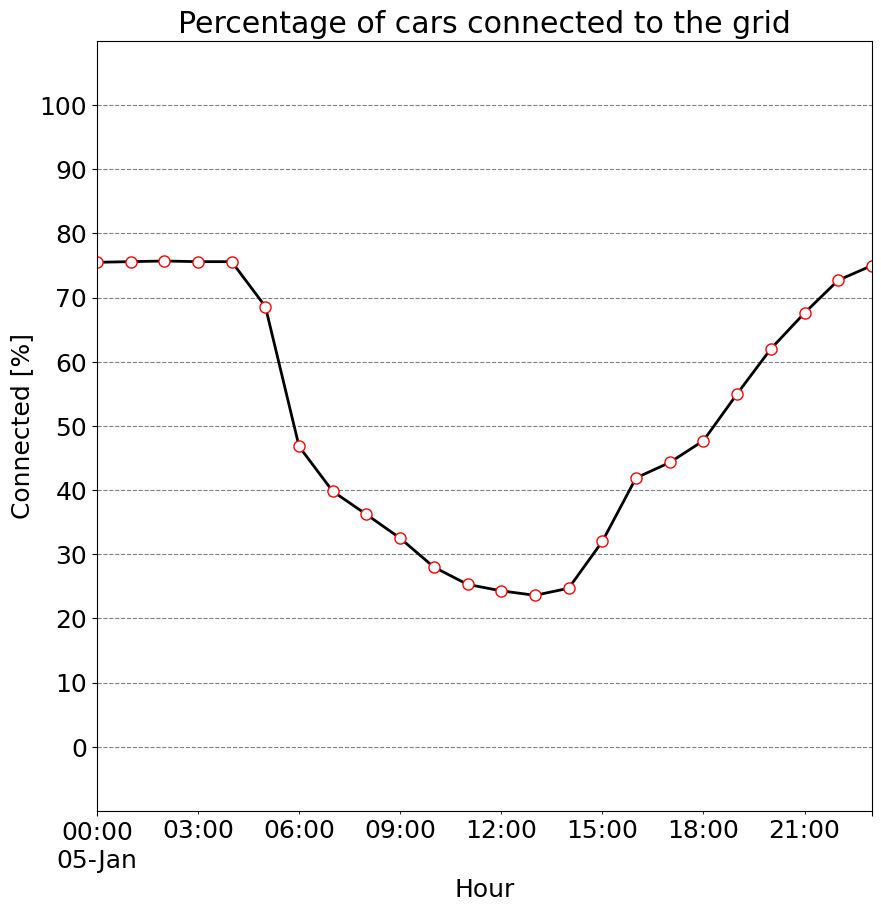

In [146]:
plot_data['connected_%']['2015-01-05'].plot(color='black', style='o-', alpha=1, figsize=(10,10), markersize=8, markerfacecolor='white', linewidth=2, markeredgecolor='red')
plt.xlabel('Hour')
plt.ylabel('Connected [%]')
plt.ylim([-10,110])
plt.yticks([0,10,20,30,40,50,60,70,80,90,100])
plt.grid(axis='y', color='gray', zorder=0, linestyle='--')
plt.title('Percentage of cars connected to the grid')
plt.show()

### Driving demand

Assume that cars only drive the hour after they are unplugged.

Read raw data

In [26]:
driving_distance = pd.read_excel('Raw/driving_distance_fylke_2015.xlsx', header=None).iloc[5:24].rename({0:'Fylke', 1:'Driving distance [10^6 km]'}, axis='columns')

In [27]:
driving_distance

,Fylke,Driving distance [10^6 km]
5,01 Østfold (-2019),2018.8
6,02 Akershus (-2019),4406.9
7,03 Oslo,3665.8
8,04 Hedmark (-2019),1604
9,05 Oppland (-2019),1474.5
10,06 Buskerud (-2019),2140
11,07 Vestfold (-2019),1633
12,08 Telemark (-2019),1182.7
13,09 Aust-Agder (-2019),850.6
14,10 Vest-Agder (-2019),1163.4


Aggregate to NUTS-2

In [28]:
driving_dict ={}

driving_dict['NO03'] = driving_distance.loc[7, 'Driving distance [10^6 km]']
driving_dict['NO11'] = driving_distance.loc[15, 'Driving distance [10^6 km]']
driving_dict['NO15'] = driving_distance.loc[18, 'Driving distance [10^6 km]']
driving_dict['NO18'] = driving_distance.loc[21, 'Driving distance [10^6 km]']
driving_dict['NO30'] = driving_distance.loc[5, 'Driving distance [10^6 km]'] + driving_distance.loc[6, 'Driving distance [10^6 km]'] + driving_distance.loc[10, 'Driving distance [10^6 km]']
driving_dict['NO34'] = driving_distance.loc[8, 'Driving distance [10^6 km]'] + driving_distance.loc[9, 'Driving distance [10^6 km]']
driving_dict['NO38'] = driving_distance.loc[11, 'Driving distance [10^6 km]'] + driving_distance.loc[12, 'Driving distance [10^6 km]']
driving_dict['NO42'] = driving_distance.loc[13, 'Driving distance [10^6 km]'] + driving_distance.loc[14, 'Driving distance [10^6 km]']
driving_dict['NO46'] = driving_distance.loc[16, 'Driving distance [10^6 km]'] + driving_distance.loc[17, 'Driving distance [10^6 km]']
driving_dict['NO50'] = driving_distance.loc[19, 'Driving distance [10^6 km]'] + driving_distance.loc[20, 'Driving distance [10^6 km]']
driving_dict['NO54'] = driving_distance.loc[22, 'Driving distance [10^6 km]'] + driving_distance.loc[23, 'Driving distance [10^6 km]']

driving_distance = pd.Series(driving_dict)

In [29]:
driving_distance = pd.DataFrame(driving_distance).rename(columns={0:'Driving distance [10^6 km]'})

Calculate driving demand per vehicle

In [30]:
driving_distance['Number of vehicles'] = vehicles
driving_distance['Driving distance per car [km]'] = (driving_distance['Driving distance [10^6 km]'] / driving_distance['Number of vehicles'])*10**6
driving_distance['Daily driving distance per car [km]'] = driving_distance['Driving distance per car [km]']/365

driving_consumption = 0.0002 # [MWh/km]
driving_distance['Daily discharge per car [MWh]'] = driving_distance['Daily driving distance per car [km]']*driving_consumption

In [31]:
demand_driving_hourly = pd.DataFrame(connected['plug_out']).rename(columns={'plug_out':0}).dot(pd.DataFrame(driving_distance['Daily discharge per car [MWh]']).rename(columns={'Daily discharge per car [MWh]':0}).T)

<AxesSubplot: >

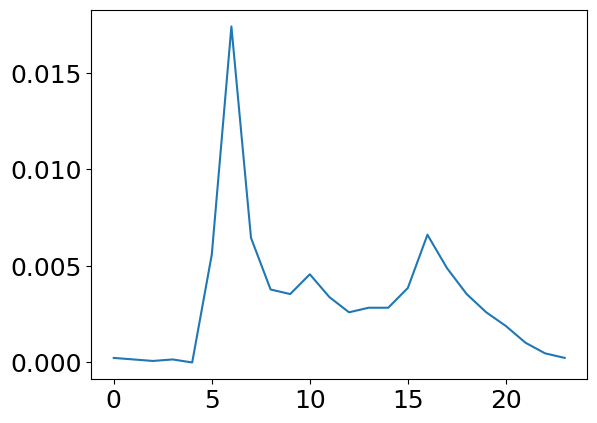

In [32]:
demand_driving_hourly.sum(axis=1)[:24].plot()

In [33]:
hourly_driving_demand = demand_driving_hourly.melt(ignore_index=False)

Write to file

In [34]:
pd.Series(hourly_driving_demand.value).set_axis((hourly_driving_demand.index).astype(str) + '.' + hourly_driving_demand.variable).to_csv('demand_driving_MWh.tsv', sep = '\t', header = False)

### Static EV charging

Calculate the static EV charging demand for weekdays, saturdays and sundays

In [35]:
result = 0
for i in vehicles.index.values:
    result += (demand_driving_hourly[i]*vehicles[i]).sum()

total_yearly_demand = result/vehicles.sum() #per car

In [36]:
# total_yearly_demand = demand_driving_hourly.sum().mean() #per car

In [37]:
total_weekly_demand = total_yearly_demand/(365/7)

In [38]:
load_curve_weekday = pd.read_csv('Raw/ev_load_curve_weekday.tsv', sep='\t', header=None, index_col=0)
load_curve_saturday = pd.read_csv('Raw/ev_load_curve_saturday.tsv', sep='\t', header=None, index_col=0)
load_curve_sunday = pd.read_csv('Raw/ev_load_curve_sunday.tsv', sep='\t', header=None, index_col=0)

In [39]:
total = 5*load_curve_weekday.sum().iloc[0] + load_curve_saturday.sum().iloc[0] + load_curve_sunday.sum().iloc[0]

weekday_weekly_fraction = (load_curve_weekday.sum().iloc[0])/total
saturday_weekly_fraction = (load_curve_saturday.sum().iloc[0])/total
sunday_weekly_fraction = (load_curve_sunday.sum().iloc[0])/total

In [40]:
weekday_demand = (load_curve_weekday/load_curve_weekday.sum())*weekday_weekly_fraction*total_weekly_demand
saturday_demand = (load_curve_saturday/load_curve_saturday.sum())*saturday_weekly_fraction*total_weekly_demand
sunday_demand = (load_curve_weekday/load_curve_weekday.sum())*sunday_weekly_fraction*total_weekly_demand

Create yearly series

In [41]:
data_dict = {}

for i in days_2015:
    if i.day_name() == 'Saturday':
        data_dict[i] = saturday_demand.values.T[0]

    elif i.day_name() == 'Sunday':
        data_dict[i] = sunday_demand.values.T[0]
    
    else:
        data_dict[i] = weekday_demand.values.T[0]
        

In [42]:
demand = pd.DataFrame(data_dict).melt(ignore_index=False).reset_index().value

Write to file

In [43]:
demand.to_csv('demand_ev_charging_MWh.tsv', sep = '\t', header = False)

### Total EV charging demand

In [44]:
(demand*(vehicles.sum())).sum()

6863730.745016961

In [45]:
result = 0
for i in vehicles.index.values:
    result += (demand_driving_hourly[i]*vehicles[i]).sum()

result

6863840.0